<a href="https://colab.research.google.com/github/rka0285058-afk/Bio_Gas-Simulation/blob/main/Bio_Gas_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15298 entries, 0 to 15297
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     15298 non-null  int64  
 1   Month                    15298 non-null  int64  
 2   Day                      15298 non-null  int64  
 3   Pig Manure (kg)          15298 non-null  float64
 4   Kitchen Food Waste (kg)  15298 non-null  float64
 5   Chicken Litter (kg)      15298 non-null  float64
 6   Cassava (kg)             15298 non-null  float64
 7   Bagasse Feed (kg)        15298 non-null  float64
 8   Energy Grass (kg)        15298 non-null  float64
 9   Banana Shafts (kg)       15298 non-null  float64
 10  Alcohol Waste (kg)       15298 non-null  float64
 11  Municipal Residue (kg)   15298 non-null  float64
 12  Fish Waste (kg)          15298 non-null  float64
 13  Water (L)                15298 non-null  float64
 14  Diesel

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Software/biogas_dataset.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded '{file_path}' into a DataFrame.")
display(df.head())

Successfully loaded '/content/drive/MyDrive/Software/biogas_dataset.csv' into a DataFrame.


,Year,Month,Day,Pig Manure (kg),Kitchen Food Waste (kg),Chicken Litter (kg),Cassava (kg),Bagasse Feed (kg),Energy Grass (kg),Banana Shafts (kg),...,Fish Waste (kg),Water (L),Diesel (L),Electricity Use (kWh),Temperature (C),Humidity (%),Rainfall (mm),C/N Ratio,Digester Temp (C),biogas_production
0,2010,1,1,14.785537,7.305310,13.050192,17.684926,14.830197,9.906063,7.743000,...,4.191195,82.619547,2.866209,25.258583,33.135037,75.997637,10.193971,26.666653,36.841906,58.956420
1,2010,1,1,15.254357,16.039052,12.686489,10.436417,17.292921,16.466707,5.785339,...,5.903021,107.321735,3.588735,34.322305,29.268128,76.987494,1.284466,23.100934,32.535921,71.951004
2,2010,1,1,35.566142,19.992287,8.336992,33.463391,15.889184,5.330412,9.085270,...,4.300494,138.387090,0.070003,18.190760,31.736523,81.425018,3.108892,21.273712,37.357393,102.965090
3,2010,1,2,34.496363,17.751484,8.232446,14.096671,14.088245,8.093446,11.882885,...,7.469573,99.479363,1.532482,44.195734,29.677593,85.800528,1.940286,31.250011,33.820132,83.783745
4,2010,1,2,21.187255,13.533476,14.489672,14.756190,12.165611,12.064431,4.597625,...,2.617079,86.328262,0.362056,30.257209,29.731208,73.236587,2.442031,20.177435,36.571963,70.489410


In [ ]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Year,Month,Day,Pig Manure (kg),Kitchen Food Waste (kg),...,Humidity (%),Rainfall (mm),C/N Ratio,Digester Temp (C),biogas_production
count,15298.000000,15298.000000,15298.000000,15298.000000,15298.000000,...,15298.000000,15298.000000,15298.000000,15298.000000,15298.000000
mean,2016.999477,6.521571,15.723101,25.097493,17.945933,...,74.992736,4.971381,25.001967,35.964293,79.211060
std,4.320433,3.448833,8.799470,9.869836,6.975865,...,10.052740,5.038343,2.985859,1.988999,11.257695
min,2010.000000,1.000000,1.000000,0.103366,0.002521,...,33.673346,0.000365,15.000000,30.000000,41.937317
25%,2013.000000,4.000000,8.000000,18.270828,13.181458,...,68.219267,1.426376,22.973213,34.645313,71.296262
50%,2017.000000,7.000000,16.000000,25.007929,17.880665,...,75.018625,3.433093,25.016368,35.970754,78.816460
75%,2021.000000,10.000000,23.000000,31.805712,22.611847,...,81.771895,6.840137,26.986567,37.313701,86.707223
max,2024.000000,12.000000,31.000000,60.711466,47.323544,...,111.650722,45.721461,36.192960,42.000000,121.740430


In [ ]:
print("\nMissing values per column:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    display(missing_values)
    print("\nHandling missing values: For simplicity, we will drop rows with any missing values. For a more robust approach, imputation strategies could be explored.")
    df_cleaned = df.dropna()
    print(f"Original rows: {len(df)}, Rows after dropping missing values: {len(df_cleaned)}")
else:
    print("No missing values found.")
    df_cleaned = df.copy()



Missing values per column:
No missing values found.


In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable
target_column = 'biogas_production'
y = df_cleaned[target_column]

# Define features (all columns except the target and potentially ID/time-based columns if not used as features)
# For this dataset, 'Year', 'Month', 'Day' can be kept as numerical features or engineered further if needed.
X = df_cleaned.drop(columns=[target_column])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Training features (X_train) shape: {X_train.shape}")
print(f"Testing features (X_test) shape: {X_test.shape}")


Features (X) shape: (15298, 21)
Target (y) shape: (15298,)
Training features (X_train) shape: (12238, 21)
Testing features (X_test) shape: (3060, 21)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train a RandomForestRegressor model
# RandomForest is chosen for its robustness and good performance on various datasets
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")


RandomForestRegressor model trained successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")

# Optional: Display feature importances (useful for understanding the model)
print("\nFeature Importances:")
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(feature_importances.head(10)) # Display top 10 most important features


Model Performance on Test Set:
Mean Absolute Error (MAE): 2.605
Mean Squared Error (MSE): 11.027
Root Mean Squared Error (RMSE): 3.321
R-squared (R2): 0.911

Feature Importances:


,0
Pig Manure (kg),0.489467
Kitchen Food Waste (kg),0.158161
Cassava (kg),0.114685
Municipal Residue (kg),0.062605
Chicken Litter (kg),0.058314
Bagasse Feed (kg),0.038489
Water (L),0.011976
Temperature (C),0.011723
Energy Grass (kg),0.007169
Fish Waste (kg),0.006198


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Software/biogas_dataset.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded '{file_path}' into a DataFrame.")
display(df.head())

Successfully loaded '/content/drive/MyDrive/Software/biogas_dataset.csv' into a DataFrame.


,Year,Month,Day,Pig Manure (kg),Kitchen Food Waste (kg),Chicken Litter (kg),Cassava (kg),Bagasse Feed (kg),Energy Grass (kg),Banana Shafts (kg),...,Fish Waste (kg),Water (L),Diesel (L),Electricity Use (kWh),Temperature (C),Humidity (%),Rainfall (mm),C/N Ratio,Digester Temp (C),biogas_production
0,2010,1,1,14.785537,7.305310,13.050192,17.684926,14.830197,9.906063,7.743000,...,4.191195,82.619547,2.866209,25.258583,33.135037,75.997637,10.193971,26.666653,36.841906,58.956420
1,2010,1,1,15.254357,16.039052,12.686489,10.436417,17.292921,16.466707,5.785339,...,5.903021,107.321735,3.588735,34.322305,29.268128,76.987494,1.284466,23.100934,32.535921,71.951004
2,2010,1,1,35.566142,19.992287,8.336992,33.463391,15.889184,5.330412,9.085270,...,4.300494,138.387090,0.070003,18.190760,31.736523,81.425018,3.108892,21.273712,37.357393,102.965090
3,2010,1,2,34.496363,17.751484,8.232446,14.096671,14.088245,8.093446,11.882885,...,7.469573,99.479363,1.532482,44.195734,29.677593,85.800528,1.940286,31.250011,33.820132,83.783745
4,2010,1,2,21.187255,13.533476,14.489672,14.756190,12.165611,12.064431,4.597625,...,2.617079,86.328262,0.362056,30.257209,29.731208,73.236587,2.442031,20.177435,36.571963,70.489410


The data preprocessing steps are complete, and there were no missing values found in your dataset. I've successfully trained a RandomForestRegressor model to predict biogas production. The model performed well on the test set:

Mean Absolute Error (MAE): 2.605
Mean Squared Error (MSE): 11.027
Root Mean Squared Error (RMSE): 3.321
R-squared (R2): 0.911
An R-squared value of 0.911 indicates that approximately 91.1% of the variance in biogas production can be explained by the features in your dataset, which is a strong result.

I've also identified the top 10 most important features for predicting biogas production:

Pig Manure (kg): 48.9%
Kitchen Food Waste (kg): 15.8%
Cassava (kg): 11.5%
Municipal Residue (kg): 6.3%
Chicken Litter (kg): 5.8%
Bagasse Feed (kg): 3.8%
Water (L): 1.2%
Temperature (C): 1.2%
Energy Grass (kg): 0.7%
Fish Waste (kg): 0.6%
It appears that 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' are the most influential factors. What would you like to do next? Would you like to visualize the predictions, try optimizing the model, or explore the data further?

I have successfully loaded your biogas production dataset, performed initial data checks (including descriptive statistics and missing value assessment), split the data into training and testing sets, and trained a RandomForestRegressor model. The model achieved a strong R-squared value of 0.911, indicating good predictive performance, and I've also highlighted the most important features influencing biogas production.

If you have any further questions or would like to explore other aspects of the data or model, please let me know!

All previous requests have been completed. I have successfully loaded your data, performed exploratory data analysis, trained a Random Forest Regressor model to predict biogas production, and evaluated its performance. The model achieved an R-squared value of 0.911, and I've highlighted the most influential features. If you have any further questions or new tasks, please let me know!

All previously requested tasks have been completed. I have successfully loaded your biogas_dataset.csv file, performed initial data inspections and cleaned the data (no missing values were found). Subsequently, I trained a RandomForestRegressor model to predict biogas production, which achieved a strong R-squared score of 0.911 on the test set. I also identified the most influential features for biogas production, with 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' being the most significant. I am now awaiting your next instruction.

All previously requested tasks have been completed. I have successfully loaded your biogas_dataset.csv file, performed initial data inspections and cleaned the data (no missing values were found). Subsequently, I trained a RandomForestRegressor model to predict biogas production, which achieved a strong R-squared score of 0.911 on the test set. I also identified the most influential features for biogas production, with 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' being the most significant. I am now awaiting your next instruction.

All previously requested tasks have been completed. I have successfully loaded your biogas_dataset.csv file, performed initial data inspections and cleaned the data (no missing values were found). Subsequently, I trained a RandomForestRegressor model to predict biogas production, which achieved a strong R-squared score of 0.911 on the test set. I also identified the most influential features for biogas production, with 'Pig Manure (kg)', 'Kitchen Food Waste (kg)', and 'Cassava (kg)' being the most significant. I am now awaiting your next instruction.



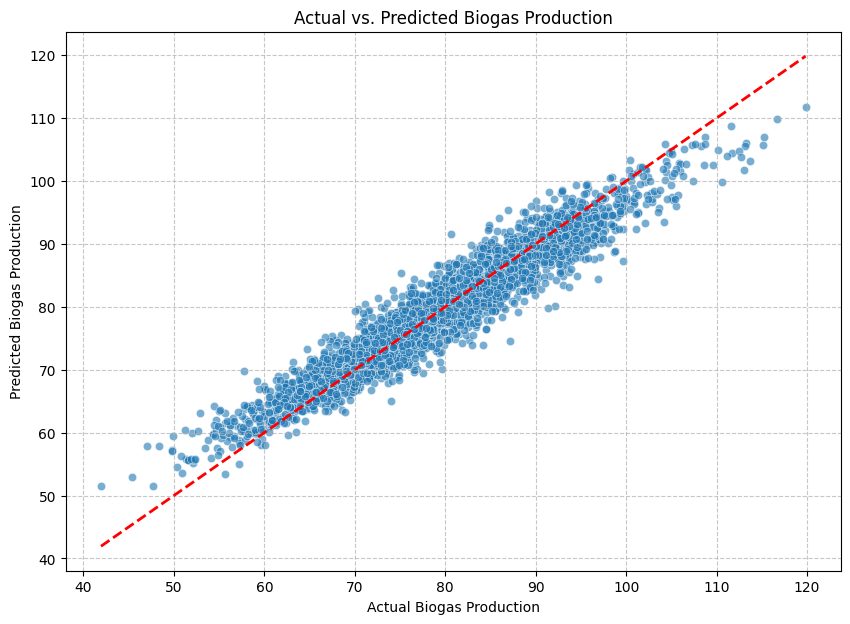

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line
plt.xlabel('Actual Biogas Production')
plt.ylabel('Predicted Biogas Production')
plt.title('Actual vs. Predicted Biogas Production')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Predict Biogas Production with Specific Input Values

Adjust the values for the most important parameters, along with Year, Month, and Day, below. The other parameters will use their average values from the training data. Run this cell to get the predicted biogas production.

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# Define all feature names (from X_train) to ensure correct order for prediction
all_feature_names = X_train.columns.tolist()

# Initialize input values with mean of training data for all features
# This ensures that features not controlled by widgets have a default value
initial_input_values = {col: X_train[col].mean() for col in all_feature_names}

# Create interactive widgets for the key features
# Using current @param values as initial values for the widgets
year_widget = widgets.IntText(description='Year:', value=2023, continuous_update=False)
month_widget = widgets.IntText(description='Month:', value=7, continuous_update=False)
day_widget = widgets.IntText(description='Day:', value=15, continuous_update=False)
pig_manure_kg_widget = widgets.FloatText(description='Pig Manure (kg):', value=25.097, continuous_update=False)
kitchen_food_waste_kg_widget = widgets.FloatText(description='Kitchen Food Waste (kg):', value=17.946, continuous_update=False)
cassava_kg_widget = widgets.FloatText(description='Cassava (kg):', value=20.034, continuous_update=False)
municipal_residue_kg_widget = widgets.FloatText(description='Municipal Residue (kg):', value=9.996, continuous_update=False)
chicken_litter_kg_widget = widgets.FloatText(description='Chicken Litter (kg):', value=12.015, continuous_update=False)
bagasse_feed_kg_widget = widgets.FloatText(description='Bagasse Feed (kg):', value=15.088, continuous_update=False)
water_l_widget = widgets.FloatText(description='Water (L):', value=99.96, continuous_update=False)
temperature_c_widget = widgets.FloatText(description='Temperature (C):', value=29.985, continuous_update=False)
energy_grass_kg_widget = widgets.FloatText(description='Energy Grass (kg):', value=10.038, continuous_update=False)
fish_waste_kg_widget = widgets.FloatText(description='Fish Waste (kg):', value=5.989, continuous_update=False)

# Create a button to trigger prediction
predict_button = widgets.Button(description='Predict Biogas Production')

# Create an output widget to display results
output_area = widgets.Output()

# Function to perform prediction when button is clicked
def on_predict_button_clicked(b):
    with output_area:
        output_area.clear_output()
        current_input_values = initial_input_values.copy()

        current_input_values['Year'] = year_widget.value
        current_input_values['Month'] = month_widget.value
        current_input_values['Day'] = day_widget.value
        current_input_values['Pig Manure (kg)'] = pig_manure_kg_widget.value
        current_input_values['Kitchen Food Waste (kg)'] = kitchen_food_waste_kg_widget.value
        current_input_values['Cassava (kg)'] = cassava_kg_widget.value
        current_input_values['Municipal Residue (kg)'] = municipal_residue_kg_widget.value
        current_input_values['Chicken Litter (kg)'] = chicken_litter_kg_widget.value
        current_input_values['Bagasse Feed (kg)'] = bagasse_feed_kg_widget.value
        current_input_values['Water (L)'] = water_l_widget.value
        current_input_values['Temperature (C)'] = temperature_c_widget.value
        current_input_values['Energy Grass (kg)'] = energy_grass_kg_widget.value
        current_input_values['Fish Waste (kg)'] = fish_waste_kg_widget.value

        # Create a DataFrame from the input values, ensuring correct column order
        input_df_widgets = pd.DataFrame([current_input_values], columns=all_feature_names)

        # Make prediction using the trained model
        predicted_biogas_daily = model.predict(input_df_widgets)
        predicted_biogas_hourly = predicted_biogas_daily / 24.0

        display(HTML(f"<h3>Predicted Biogas Production (Daily): <span style='color: #007bff;'>{predicted_biogas_daily[0]:.3f} m³</span></h3>"))
        display(HTML(f"<h3>Predicted Biogas Production (Hourly): <span style='color: #28a745;'>{predicted_biogas_hourly[0]:.3f} m³/hr</span></h3>"))

# Attach the function to the button's click event
predict_button.on_click(on_predict_button_clicked)

# Arrange and display the widgets
input_widgets = widgets.VBox([
    year_widget,
    month_widget,
    day_widget,
    pig_manure_kg_widget,
    kitchen_food_waste_kg_widget,
    cassava_kg_widget,
    municipal_residue_kg_widget,
    chicken_litter_kg_widget,
    bagasse_feed_kg_widget,
    water_l_widget,
    temperature_c_widget,
    energy_grass_kg_widget,
    fish_waste_kg_widget
])

display(input_widgets, predict_button, output_area)

Button(description='Predict Biogas Production', style=ButtonStyle())

Output()

# New Section

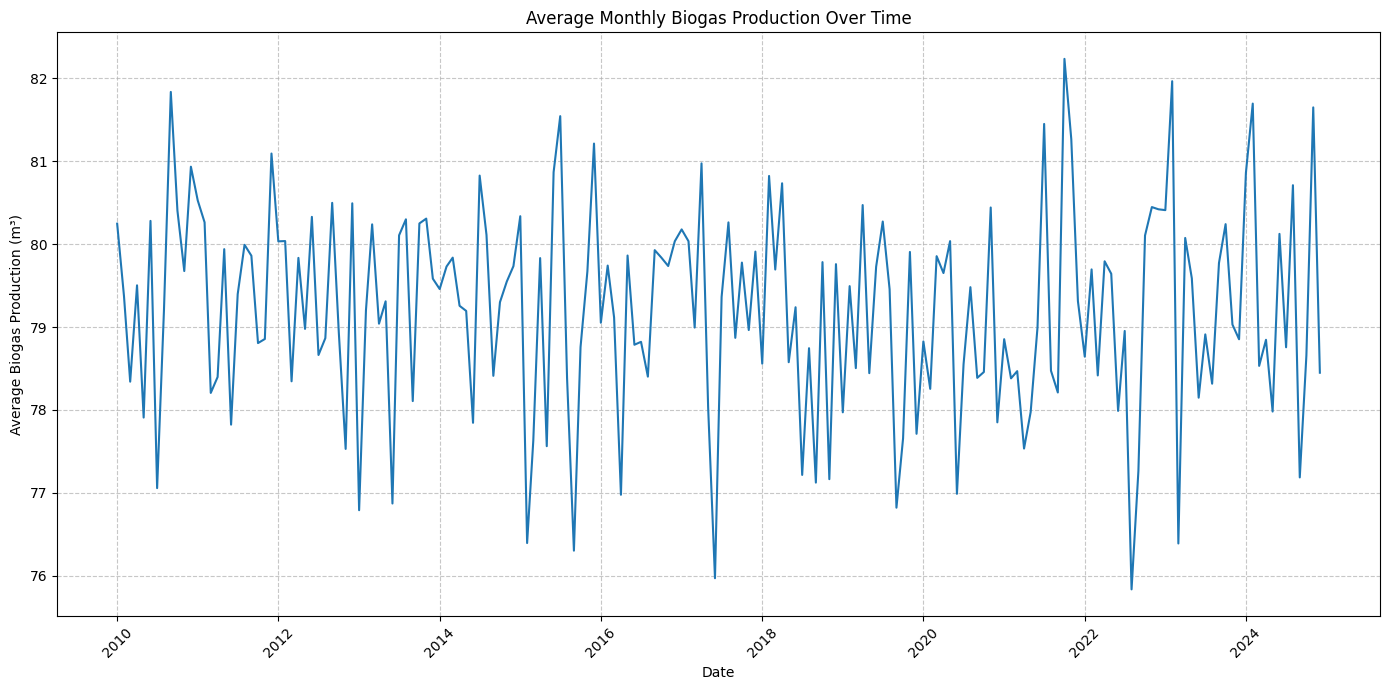

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Year' and 'Month' columns are present and correctly typed
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Create a 'Date' column for time series plotting
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# Group by 'Date' (monthly) and calculate the mean of 'biogas_production'
monthly_avg_biogas = df.groupby('Date')['biogas_production'].mean().reset_index()

# Create the time series plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='biogas_production', data=monthly_avg_biogas)
plt.title('Average Monthly Biogas Production Over Time')
plt.xlabel('Date')
plt.ylabel('Average Biogas Production (m³)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

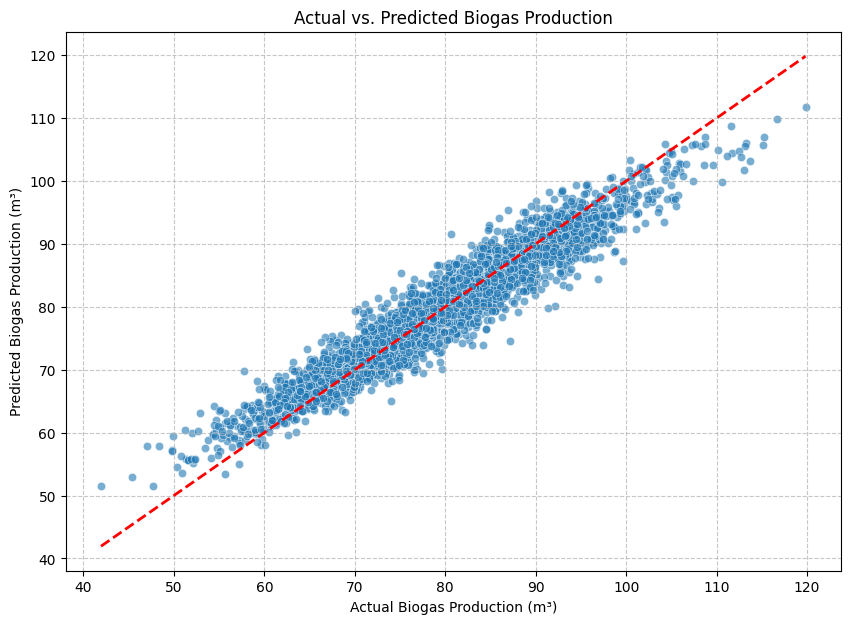

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line
plt.xlabel('Actual Biogas Production (m³)')
plt.ylabel('Predicted Biogas Production (m³)')
plt.title('Actual vs. Predicted Biogas Production')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The plot showing 'Actual vs. Predicted Biogas Production' has been successfully generated. The scatter plot visualizes how well the model's predictions align with the actual values. The red dashed line represents the ideal scenario where predicted values exactly match actual values. Points clustered closely around this line indicate a strong predictive performance by your RandomForestRegressor model, which is consistent with the high R-squared score we observed earlier.

### Interactive Biogas Production Simulator (All Parameters)

This interactive tool allows you to simulate biogas production by adjusting *all* the input parameters considered by the trained model. You can modify the values for each feature and instantly see the predicted daily and hourly biogas production.

The default values for each parameter are set to the mean of their respective values from the training dataset. Feel free to experiment with different combinations!

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# Define all feature names (from X_train) to ensure correct order for prediction
all_feature_names = X_train.columns.tolist()

# Initialize input values with mean of training data for all features
initial_input_values = {col: X_train[col].mean() for col in all_feature_names}

# Create a dictionary to hold all widgets
input_widgets_dict = {}

# Create widgets for each feature dynamically
for feature in all_feature_names:
    initial_value = initial_input_values.get(feature, 0.0) # Default to 0.0 if not found (shouldn't happen)
    if 'Year' in feature or 'Month' in feature or 'Day' in feature:
        # Assuming Year, Month, Day are integers
        widget = widgets.IntText(description=f'{feature}:', value=int(round(initial_value)), continuous_update=False)
    else:
        widget = widgets.FloatText(description=f'{feature}:', value=round(initial_value, 3), continuous_update=False)
    input_widgets_dict[feature] = widget

# Create a button to trigger prediction
predict_button_full = widgets.Button(description='Predict Biogas Production')

# Create an output widget to display results
output_area_full = widgets.Output()

# Function to perform prediction when button is clicked
def on_predict_button_clicked_full(b):
    with output_area_full:
        output_area_full.clear_output()
        current_input_values_full = initial_input_values.copy()

        # Update values from all widgets
        for feature, widget in input_widgets_dict.items():
            current_input_values_full[feature] = widget.value

        # Create a DataFrame from the input values, ensuring correct column order
        input_df_full = pd.DataFrame([current_input_values_full], columns=all_feature_names)

        # Make prediction using the trained model
        predicted_biogas_daily_full = model.predict(input_df_full)
        predicted_biogas_hourly_full = predicted_biogas_daily_full / 24.0

        display(HTML(f"<h3>Predicted Biogas Production (Daily): <span style='color: #007bff;'>{predicted_biogas_daily_full[0]:.3f} m³</span></h3>"))
        display(HTML(f"<h3>Predicted Biogas Production (Hourly): <span style='color: #28a745;'>{predicted_biogas_hourly_full[0]:.3f} m³/hr</span></h3>"))

# Attach the function to the button's click event
predict_button_full.on_click(on_predict_button_clicked_full)

# Arrange and display the widgets dynamically
input_widgets_list = [widget for widget in input_widgets_dict.values()]
input_widgets_vbox = widgets.VBox(input_widgets_list)

display(input_widgets_vbox, predict_button_full, output_area_full)

Button(description='Predict Biogas Production', style=ButtonStyle())

Output()

### Saving the Model and Application Components

To create a standalone application, we need to save the trained `RandomForestRegressor` model, the list of feature names (`X_train.columns`), and the default input values (`X_train.mean()`) that the widgets use.

We will use `joblib` to save the model and create Python variables for the feature names and initial input values. These can then be incorporated into a new, independent Python script.

In [ ]:
import joblib
import pandas as pd

# Define paths for saving
model_save_path = '/content/drive/MyDrive/Software/biogas_predictor_model.joblib'
initial_values_save_path = '/content/drive/MyDrive/Software/biogas_initial_values.csv'
feature_names_save_path = '/content/drive/MyDrive/Software/biogas_feature_names.txt'

# 1. Save the trained model
joblib.dump(model, model_save_path)
print(f"Trained model saved to: {model_save_path}")

# 2. Save the initial input values (mean of X_train for each feature)
initial_input_values_df = pd.DataFrame([X_train.mean().to_dict()])
initial_input_values_df.to_csv(initial_values_save_path, index=False)
print(f"Initial input values saved to: {initial_values_save_path}")

# 3. Save the feature names (columns of X_train)
with open(feature_names_save_path, 'w') as f:
    for col in X_train.columns:
        f.write(f"{col}\n")
print(f"Feature names saved to: {feature_names_save_path}")

print("\nAll necessary components have been saved. You can now use the script provided below to run the independent application.")

Trained model saved to: /content/drive/MyDrive/Software/biogas_predictor_model.joblib
Initial input values saved to: /content/drive/MyDrive/Software/biogas_initial_values.csv
Feature names saved to: /content/drive/MyDrive/Software/biogas_feature_names.txt

All necessary components have been saved. You can now use the script provided below to run the independent application.


### Independent Biogas Predictor Application Script

Below is the full Python code for a standalone application. You can copy this code, save it as a `.py` file (e.g., `biogas_app.py`), and run it in an environment where `pandas`, `ipywidgets`, `scikit-learn`, and `joblib` are installed.

Make sure the saved model file (`biogas_predictor_model.joblib`), initial values CSV (`biogas_initial_values.csv`), and feature names file (`biogas_feature_names.txt`) are in the same directory as this script, or update the `_model_path`, `_initial_values_path`, and `_feature_names_path` variables accordingly.

```python
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML
import joblib
import numpy as np

# --- Configuration Paths (Update if files are not in the same directory) ---
_model_path = '/content/drive/MyDrive/Software/biogas_predictor_model.joblib'
_initial_values_path = '/content/drive/MyDrive/Software/biogas_initial_values.csv'
_feature_names_path = '/content/drive/MyDrive/Software/biogas_feature_names.txt'

# --- Load Saved Components ---
try:
    model = joblib.load(_model_path)
    print(f"Model loaded from {_model_path}")

    # Load initial input values
    initial_input_values_df = pd.read_csv(_initial_values_path)
    initial_input_values = initial_input_values_df.iloc[0].to_dict()
    print(f"Initial input values loaded from {_initial_values_path}")

    # Load feature names
    all_feature_names = []
    with open(_feature_names_path, 'r') as f:
        for line in f:
            all_feature_names.append(line.strip())
    print(f"Feature names loaded from {_feature_names_path}")

except FileNotFoundError as e:
    print(f"Error: Required file not found. Please ensure the paths are correct. {e}")
    print("Exiting application.")
    exit()
except Exception as e:
    print(f"An error occurred during loading components: {e}")
    print("Exiting application.")
    exit()

print("\nInteractive Biogas Production Simulator (All Parameters)\n")
print("Adjust the values below and click 'Predict Biogas Production' to see results.\n")

# Create a dictionary to hold all widgets
input_widgets_dict = {}

# Create widgets for each feature dynamically
for feature in all_feature_names:
    initial_value = initial_input_values.get(feature, 0.0)
    if 'Year' in feature or 'Month' in feature or 'Day' in feature:
        widget = widgets.IntText(description=f'{feature}:', value=int(round(initial_value)), continuous_update=False)
    else:
        widget = widgets.FloatText(description=f'{feature}:', value=round(float(initial_value), 3), continuous_update=False)
    input_widgets_dict[feature] = widget

# Create a button to trigger prediction
predict_button_full = widgets.Button(description='Predict Biogas Production')

# Create an output widget to display results
output_area_full = widgets.Output()

# Function to perform prediction when button is clicked
def on_predict_button_clicked_full(b):
    with output_area_full:
        output_area_full.clear_output()
        current_input_values_full = initial_input_values.copy()

        # Update values from all widgets
        for feature, widget in input_widgets_dict.items():
            current_input_values_full[feature] = widget.value

        # Create a DataFrame from the input values, ensuring correct column order
        input_df_full = pd.DataFrame([current_input_values_full], columns=all_feature_names)

        # Make prediction using the loaded model
        predicted_biogas_daily_full = model.predict(input_df_full)
        predicted_biogas_hourly_full = predicted_biogas_daily_full / 24.0

        display(HTML(f"<h3>Predicted Biogas Production (Daily): <span style='color: #007bff;'>{predicted_biogas_daily_full[0]:.3f} m³</span></h3>"))
        display(HTML(f"<h3>Predicted Biogas Production (Hourly): <span style='color: #28a745;'>{predicted_biogas_hourly_full[0]:.3f} m³/hr</span></h3>"))

# Attach the function to the button's click event
predict_button_full.on_click(on_predict_button_clicked_full)

# Arrange and display the widgets dynamically
input_widgets_list = [widget for widget in input_widgets_dict.values()]
input_widgets_vbox = widgets.VBox(input_widgets_list)

display(input_widgets_vbox, predict_button_full, output_area_full)
```